[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)
[![Run in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)

# 04 - Statistical Regression Detection & Deployment Gate

**Goal:** Validate the complete statistical regression detection pipeline and deployment gate before locking down production extractions in `src/nirizan/`.

**Core Question Answered:** Given historical baseline runs and a newly evaluated candidate run, can NiriZan mathematically prove whether quality has genuinely regressed, quantify statistical confidence, assign actionable severity levels, and issue an automated deployment decision (PASS / FAIL)?

### Advanced Features Addressed:
1. **Statistical Rigor:** Non-parametric testing (Mann-Whitney U), Multiple Testing Corrections (Holm-Bonferroni), Standardized Effect Sizing (Cohen's d), Bootstrap Confidence Intervals (Approach B) on decision-driving score deltas, and Sample Size Determination.
2. **Data Hygiene:** Sliding Window Baselines, Dataset Version Locking, Outlier Purging (MAD).
3. **Subgroup Evaluation:** Metadata Slicing.
4. **Contract-Compliant Schemas:** Pydantic `BaseModel` contract integration (`RegressionVerdict`, `GateVerdict`, `RegressionSeverity`).
5. **Operational Readiness:** CI Integration Logic (GitHub Actions JSON/Markdown exports, Exit codes).

## Section 1: Imports & Environment Setup

In [ ]:
import math
import json
import sys
from datetime import datetime, timezone
from enum import Enum
from uuid import uuid4, UUID
from typing import List, Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pydantic import BaseModel, Field, ConfigDict

print("Environment initialized successfully.")

Environment initialized successfully.


## Section 2: Input/Output Data Validation (Pydantic Schemas)
Strict schema enforcement ensures that evaluation payloads entering the gate are well-formed and contain necessary metadata for slicing, versioning, and end-to-end lineage tracing.

In [ ]:
class MetricResultPayload(BaseModel):
    model_config = ConfigDict(strict=True)
    name: str
    scores: List[float] = Field(..., min_length=1)
    metadata: Dict[str, str] = Field(default_factory=dict)


class EvaluationRunPayload(BaseModel):
    model_config = ConfigDict(strict=True)
    run_id: UUID
    commit_sha: str
    dataset_version: str
    metrics: List[MetricResultPayload]


class RegressionSeverity(str, Enum):
    NONE = "none"
    WARNING = "warning"
    BLOCKING = "blocking"


class RegressionVerdict(BaseModel):
    model_config = ConfigDict(strict=True)

    metric_name: str
    severity: RegressionSeverity
    z_score: float | None = None
    p_value: float | None = Field(default=None, ge=0.0, le=1.0)
    effect_size: float | None = None
    baseline_id: UUID
    run_id: UUID
    explanation: str


class GateVerdict(BaseModel):
    model_config = ConfigDict(strict=True)

    passed: bool
    exit_code: int
    confidence_interval: Tuple[float, float]
    verdicts: List[RegressionVerdict]


print("Pydantic schemas initialized successfully.")

Pydantic schemas initialized successfully.


## Section 3: Baseline Management & Data Hygiene
1. **Sliding Window Baseline:** Restrict baseline to last $K$ runs to prevent sample size inflation and hide baseline drift.
2. **Dataset Version Locking:** Candidate and baseline must share the same `dataset_version`.
3. **Outlier Purging:** Automated exclusion of corrupted evaluation scores (e.g., API rate limits or timeout spikes) using Median Absolute Deviation (MAD).

In [ ]:
def purge_outliers_mad(scores: List[float], threshold: float = 3.5) -> List[float]:
    """Remove score anomalies using Median Absolute Deviation (MAD)."""
    if len(scores) < 3:
        return scores

    arr = np.array(scores)
    med = np.median(arr)
    mad = np.median(np.abs(arr - med))

    if mad == 0:
        return scores

    mod_z = 0.6745 * np.abs(arr - med) / mad
    return arr[mod_z <= threshold].tolist()


def get_sliding_window_baseline(
    runs: List[EvaluationRunPayload], window_size: int = 5
) -> List[EvaluationRunPayload]:
    """Restrict to the last K runs to prevent sample size inflation and mask drift."""
    return runs[-window_size:]


def verify_dataset_lock(
    candidate: EvaluationRunPayload, baseline: List[EvaluationRunPayload]
) -> bool:
    """Ensure candidate and baseline ran on identical dataset versions."""
    base_versions = {r.dataset_version for r in baseline}
    return len(base_versions) == 1 and candidate.dataset_version in base_versions

## Section 4: Subgroup / Sliced Evaluation & Mock Data Generation
Global metric averages obscure localized failures. The gate evaluates metrics sliced by metadata tags.

In [ ]:
def slice_by_metadata(
    run: EvaluationRunPayload, tag_key: str, tag_value: str
) -> Dict[str, List[float]]:
    """Extract scores for metrics filtered by a specific metadata tag."""
    sliced_scores = {}
    for metric in run.metrics:
        if metric.metadata.get(tag_key) == tag_value:
            sliced_scores[metric.name] = metric.scores
    return sliced_scores


def generate_baseline_runs(ds_version: str = "v1.2") -> List[EvaluationRunPayload]:
    """Generate mock historical baseline runs across multiple metrics."""
    runs = []
    commits = ["a1b2c3d", "e4f5g6h", "7i8j9k0", "l1m2n3o", "p4q5r6s"]
    np.random.seed(42)

    for commit in commits:
        metrics = [
            MetricResultPayload(
                name="groundedness",
                scores=np.clip(np.random.normal(0.89, 0.02, 50), 0.0, 1.0).tolist(),
                metadata={"context_length": "long", "topic": "finance"},
            ),
            MetricResultPayload(
                name="context_relevance",
                scores=np.clip(np.random.normal(0.85, 0.03, 50), 0.0, 1.0).tolist(),
                metadata={"context_length": "long", "topic": "finance"},
            ),
            MetricResultPayload(
                name="answer_relevance",
                scores=np.clip(np.random.normal(0.92, 0.015, 50), 0.0, 1.0).tolist(),
                metadata={"context_length": "long", "topic": "finance"},
            ),
        ]
        runs.append(
            EvaluationRunPayload(
                run_id=uuid4(), commit_sha=commit, dataset_version=ds_version, metrics=metrics
            )
        )
    return runs

## Section 5: Statistical Formulations & Methodology

#### 1. Mann-Whitney U Rank Statistic
The Mann-Whitney U test evaluates whether candidate scores are stochastically smaller than baseline scores without assuming normality. Ranks $R_1$ and $R_2$ are calculated across combined samples $n_1$ and $n_2$:

$$U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}, \quad U_2 = R_2 - \frac{n_2(n_2 + 1)}{2}$$

$$U = \min(U_1, U_2)$$

#### 2. Cohen's $d$ Effect Size
Quantifies the standardized mean difference between candidate ($\bar{X}_{\text{cand}}$) and baseline ($\bar{X}_{\text{base}}$) distributions:

$$d = \frac{\bar{X}_{\text{cand}} - \bar{X}_{\text{base}}}{s_{\text{pooled}}}$$

where $s_{\text{pooled}}$ is defined as:

$$s_{\text{pooled}} = \sqrt{\frac{s_{\text{cand}}^2 + s_{\text{base}}^2}{2}}$$

#### 3. Bootstrap Confidence Interval (Approach B)
Computes a non-parametric 95% bootstrap confidence interval on the score delta ($\Delta = \bar{X}_{\text{cand}} - \bar{X}_{\text{base}}$) for the primary decision-driving metric:

$$\text{CI}_{95\%} = \left[ Q_{0.025}\left(\{\hat{\Delta}^*_b\}\right), \, Q_{0.975}\left(\{\hat{\Delta}^*_b\}\right) \right]$$

#### 4. Sample Size Determination (Power Analysis)
Computes the sample size $N$ required to detect a target regression drop $\delta$ with power $1 - \beta = 0.80$ at a one-tailed significance level $\alpha = 0.05$ ($Z_{\alpha} = 1.645$):

$$N = \left\lceil \frac{2 \cdot \left(Z_{\alpha} + Z_{\beta}\right)^2 \cdot \sigma^2}{\delta^2} \right\rceil$$

In [ ]:
def eval_mann_whitney_u(cand_scores: List[float], base_scores: List[float]) -> Tuple[float, float]:
    """Non-parametric one-tailed test for score degradation."""
    if len(cand_scores) < 5 or len(base_scores) < 5:
        return 0.0, 1.0
    stat, p_value = mannwhitneyu(cand_scores, base_scores, alternative="less")
    return float(stat), float(p_value)


def eval_cohens_d(cand_scores: List[float], base_scores: List[float]) -> float:
    """Calculate standardized effect size (Cohen's d)."""
    c_mean, b_mean = np.mean(cand_scores), np.mean(base_scores)
    c_std, b_std = np.std(cand_scores, ddof=1), np.std(base_scores, ddof=1)
    pooled_std = math.sqrt((c_std**2 + b_std**2) / 2)
    return float((c_mean - b_mean) / pooled_std) if pooled_std > 0 else 0.0


def compute_bootstrap_ci(
    cand_scores: List[float],
    base_scores: List[float],
    n_bootstraps: int = 1000,
    ci_level: float = 0.95,
    seed: int = 42,
) -> Tuple[float, float]:
    """Compute non-parametric bootstrap confidence interval for score delta (candidate - baseline)."""
    if not cand_scores or not base_scores:
        return (0.0, 0.0)

    rng = np.random.default_rng(seed)
    cand_arr = np.array(cand_scores)
    base_arr = np.array(base_scores)

    cand_boot = rng.choice(cand_arr, size=(n_bootstraps, len(cand_arr)), replace=True)
    base_boot = rng.choice(base_arr, size=(n_bootstraps, len(base_arr)), replace=True)

    deltas = np.mean(cand_boot, axis=1) - np.mean(base_boot, axis=1)

    lower_p = (1.0 - ci_level) / 2.0 * 100.0
    upper_p = (1.0 + ci_level) / 2.0 * 100.0

    ci_lower = float(np.percentile(deltas, lower_p))
    ci_upper = float(np.percentile(deltas, upper_p))

    return (round(ci_lower, 4), round(ci_upper, 4))


def determine_sample_size(
    base_std: float, delta: float, alpha: float = 0.05, power: float = 0.8
) -> int:
    """Sample size calculator using one-tailed Z-critical values."""
    z_alpha = 1.645  # One-tailed alpha = 0.05
    z_beta = 0.84  # Power = 0.80 (beta = 0.20)
    if delta == 0:
        return 0
    return int(math.ceil(2 * ((z_alpha + z_beta) * base_std / delta) ** 2))

## Section 6: Multiple Testing Correction (Holm-Bonferroni)

When evaluating $M$ metrics simultaneously, the probability of at least one false positive scales as $\text{FWER} = 1 - (1 - \alpha)^M$.

To control the Family-Wise Error Rate (FWER), $p$-values are sorted in ascending order $p_{(1)} \le p_{(2)} \le \dots \le p_{(M)}$ and evaluated sequentially against an adjusted threshold $\alpha_{(i)}$:

$$\alpha_{(i)} = \frac{\alpha}{M - i + 1}$$

The step-down procedure stops at the first index $k$ where $p_{(k)} > \alpha_{(k)}$, failing to reject all remaining null hypotheses $H_{(k)} \dots H_{(M)}$.

In [ ]:
def holm_bonferroni(p_values: List[float], alpha: float = 0.05) -> List[bool]:
    """Adjust p-values using Holm-Bonferroni step-down procedure."""
    m = len(p_values)
    if m == 0:
        return []

    sorted_indices = np.argsort(p_values)
    rejected = [False] * m

    for i, idx in enumerate(sorted_indices):
        adjusted_alpha = alpha / (m - i)
        if p_values[idx] <= adjusted_alpha:
            rejected[idx] = True
        else:
            break

    return rejected

## Section 7: Comparator & Deployment Gate Implementation

Combines non-parametric statistical testing ($p$-value + effect size) and produces Pydantic-compliant `RegressionVerdict` and `GateVerdict` models.

In [ ]:
class BaselineComparator:
    def __init__(self, effect_size_warning: float = 0.2, effect_size_blocking: float = 0.5):
        self.effect_size_warning = effect_size_warning
        self.effect_size_blocking = effect_size_blocking

    def compare_metric(
        self,
        metric_name: str,
        cand_scores: List[float],
        base_scores: List[float],
        baseline_id: UUID,
        run_id: UUID,
    ) -> RegressionVerdict:
        if not cand_scores or not base_scores:
            return RegressionVerdict(
                metric_name=metric_name,
                severity=RegressionSeverity.NONE,
                z_score=None,
                p_value=1.0,
                effect_size=0.0,
                baseline_id=baseline_id,
                run_id=run_id,
                explanation="Insufficient data",
            )

        _, p_val = eval_mann_whitney_u(cand_scores, base_scores)
        effect = eval_cohens_d(cand_scores, base_scores)

        is_sig = p_val < 0.05

        if is_sig and effect < -self.effect_size_blocking:
            severity = RegressionSeverity.BLOCKING
            explanation = f"Severe regression detected (p={p_val:.4e}, d={effect:.2f})"
        elif is_sig and effect < -self.effect_size_warning:
            severity = RegressionSeverity.WARNING
            explanation = f"Moderate regression detected (p={p_val:.4e}, d={effect:.2f})"
        else:
            severity = RegressionSeverity.NONE
            explanation = f"No significant regression (p={p_val:.4f}, d={effect:.2f})"

        return RegressionVerdict(
            metric_name=metric_name,
            severity=severity,
            z_score=None,
            p_value=p_val,
            effect_size=effect,
            baseline_id=baseline_id,
            run_id=run_id,
            explanation=explanation,
        )


class DeploymentGate:
    def evaluate(
        self,
        verdicts: List[RegressionVerdict],
        scores_by_metric: Dict[str, Tuple[List[float], List[float]]],
    ) -> GateVerdict:
        if not verdicts:
            return GateVerdict(
                passed=True, exit_code=0, confidence_interval=(0.0, 0.0), verdicts=[]
            )

        has_blocking = any(v.severity == RegressionSeverity.BLOCKING for v in verdicts)
        passed = not has_blocking

        # Select decision-driving metric (highest severity level, then most negative effect size)
        severity_weights = {
            RegressionSeverity.BLOCKING: 3,
            RegressionSeverity.WARNING: 2,
            RegressionSeverity.NONE: 1,
        }

        decision_metric_verdict = min(
            verdicts,
            key=lambda v: (
                -severity_weights[v.severity],
                v.effect_size if v.effect_size is not None else 0.0,
            ),
        )

        # Approach B: Compute bootstrap CI on actual score delta of the decision-driving metric
        metric_name = decision_metric_verdict.metric_name
        cand_scores, base_scores = scores_by_metric.get(metric_name, ([], []))
        ci = compute_bootstrap_ci(cand_scores, base_scores)

        return GateVerdict(
            passed=passed, exit_code=0 if passed else 1, confidence_interval=ci, verdicts=verdicts
        )

## Section 8: Operational Architecture & CI/CD Pipeline Simulation

Simulates execution inside GitHub Actions. Enforces dataset locks, applies sliding windows, purges outliers, calculates Holm-Bonferroni corrections, computes Approach B confidence intervals, and outputs structured artifacts.

In [ ]:
def simulate_ci_pipeline(
    candidate_run: EvaluationRunPayload, baseline_runs: List[EvaluationRunPayload]
) -> int:
    print("=== SIMULATED GITHUB ACTIONS RUN ===")

    # 1. Dataset Version Check
    if not verify_dataset_lock(candidate_run, baseline_runs):
        print("::error::Dataset version mismatch. Deployment blocked.")
        return 1

    # 2. Sliding Window Baseline
    baseline_window = get_sliding_window_baseline(baseline_runs, window_size=3)
    baseline_id = baseline_window[-1].run_id
    run_id = candidate_run.run_id

    comp = BaselineComparator()
    gate = DeploymentGate()
    metric_verdicts = []
    p_values = []
    scores_by_metric = {}

    # 3. Subgroup Evaluation Slicing
    sliced_candidate = slice_by_metadata(candidate_run, "context_length", "long")

    for m_name, cand_scores in sliced_candidate.items():
        base_scores = []
        for r in baseline_window:
            base_scores.extend(slice_by_metadata(r, "context_length", "long").get(m_name, []))

        clean_cand = purge_outliers_mad(cand_scores)
        clean_base = purge_outliers_mad(base_scores)

        scores_by_metric[m_name] = (clean_cand, clean_base)

        verdict = comp.compare_metric(
            m_name, clean_cand, clean_base, baseline_id=baseline_id, run_id=run_id
        )
        metric_verdicts.append(verdict)
        p_values.append(verdict.p_value)

    # 4. Multiple Testing Correction
    rejections = holm_bonferroni(p_values)
    for i, v in enumerate(metric_verdicts):
        if not rejections[i] and v.severity != RegressionSeverity.NONE:
            metric_verdicts[i] = RegressionVerdict(
                metric_name=v.metric_name,
                severity=RegressionSeverity.NONE,
                z_score=v.z_score,
                p_value=v.p_value,
                effect_size=v.effect_size,
                baseline_id=v.baseline_id,
                run_id=v.run_id,
                explanation="Failed Holm-Bonferroni significance threshold",
            )

    # 5. Evaluate Gate
    gate_verdict = gate.evaluate(metric_verdicts, scores_by_metric)

    # 6. Export Summary JSON and PR Markdown
    summary_json = {
        "passed": gate_verdict.passed,
        "confidence_interval": list(gate_verdict.confidence_interval),
        "verdicts": [
            {
                "metric": v.metric_name,
                "severity": v.severity.value,
                "p_value": v.p_value,
                "effect_size": v.effect_size,
                "baseline_id": str(v.baseline_id),
                "run_id": str(v.run_id),
            }
            for v in gate_verdict.verdicts
        ],
    }
    print(f"::set-output name=gate_summary::{json.dumps(summary_json)}")

    print("\n| Metric | Severity | P-Value | Cohen's d | Explanation |")
    print("|--------|----------|---------|-----------|-------------|")
    for v in gate_verdict.verdicts:
        print(
            f"| {v.metric_name} | {v.severity.value} | {v.p_value:.4f} | {v.effect_size:.2f} | {v.explanation} |"
        )

    print(
        f"\nDecision-Driving Metric Score Delta 95% Bootstrap CI: {gate_verdict.confidence_interval}"
    )
    print(
        f"Pipeline Exit Code: {gate_verdict.exit_code} ({'SUCCESS' if gate_verdict.passed else 'DEPLOYMENT BLOCKED'})"
    )
    return gate_verdict.exit_code

## Section 9: Multi-Metric Test Suite, Execution & Distribution Visualization

Minimum samples required to reliably detect a 0.03 metric drop (std=0.02): 6

--- Running Good Candidate ---
=== SIMULATED GITHUB ACTIONS RUN ===
::set-output name=gate_summary::{"passed": true, "confidence_interval": [-0.0092, 0.0037], "verdicts": [{"metric": "groundedness", "severity": "none", "p_value": 0.2541092562949061, "effect_size": -0.11005776195614558, "baseline_id": "a76f178c-e1e6-41f0-a846-70ae0a86b2ac", "run_id": "2a0f7d11-b909-4d5e-92c7-62ba3fcc35ae"}, {"metric": "context_relevance", "severity": "none", "p_value": 0.6094578073018612, "effect_size": 0.07895960547309469, "baseline_id": "a76f178c-e1e6-41f0-a846-70ae0a86b2ac", "run_id": "2a0f7d11-b909-4d5e-92c7-62ba3fcc35ae"}, {"metric": "answer_relevance", "severity": "none", "p_value": 0.9180921211159982, "effect_size": 0.2698646689686144, "baseline_id": "a76f178c-e1e6-41f0-a846-70ae0a86b2ac", "run_id": "2a0f7d11-b909-4d5e-92c7-62ba3fcc35ae"}]}

| Metric | Severity | P-Value | Cohen's d | Explanation |
|--------|----------|

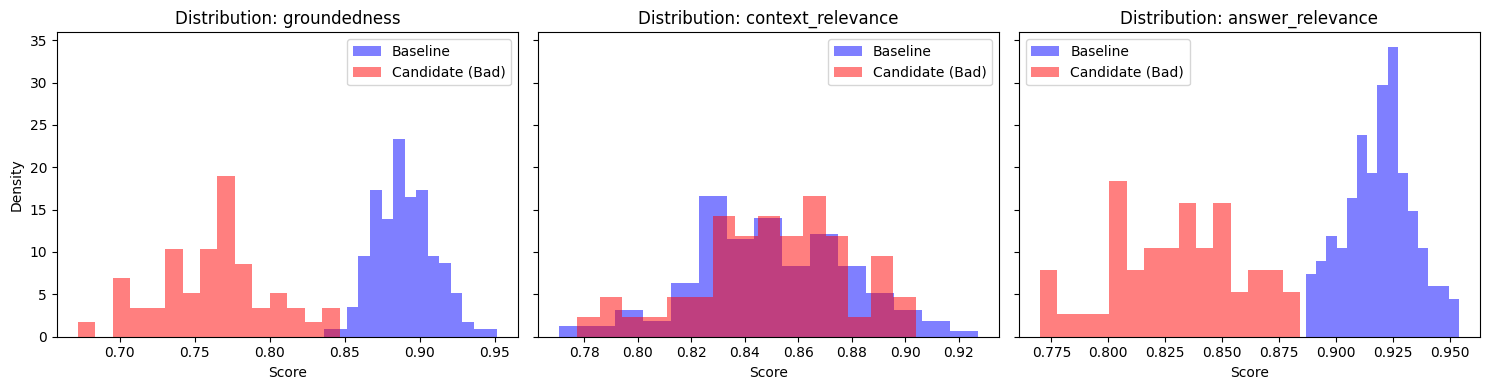

In [ ]:
# Generate mock baselines
baseline_runs = generate_baseline_runs()

# 1. Multi-metric Pass Candidate
good_metrics = [
    MetricResultPayload(
        name="groundedness",
        scores=np.clip(np.random.normal(0.885, 0.02, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
    MetricResultPayload(
        name="context_relevance",
        scores=np.clip(np.random.normal(0.848, 0.03, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
    MetricResultPayload(
        name="answer_relevance",
        scores=np.clip(np.random.normal(0.918, 0.015, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
]
good_candidate = EvaluationRunPayload(
    run_id=uuid4(), commit_sha="good123", dataset_version="v1.2", metrics=good_metrics
)

# 2. Multi-metric Fail Candidate (Groundedness and Answer Relevance Regress)
bad_metrics = [
    MetricResultPayload(
        name="groundedness",
        scores=np.clip(np.random.normal(0.760, 0.04, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
    MetricResultPayload(
        name="context_relevance",
        scores=np.clip(np.random.normal(0.850, 0.03, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
    MetricResultPayload(
        name="answer_relevance",
        scores=np.clip(np.random.normal(0.820, 0.03, 50), 0, 1).tolist(),
        metadata={"context_length": "long"},
    ),
]
bad_candidate = EvaluationRunPayload(
    run_id=uuid4(), commit_sha="bad123", dataset_version="v1.2", metrics=bad_metrics
)

# Power Analysis
required_n = determine_sample_size(base_std=0.02, delta=0.03)
print(f"Minimum samples required to reliably detect a 0.03 metric drop (std=0.02): {required_n}\n")

print("--- Running Good Candidate ---")
exit_good = simulate_ci_pipeline(good_candidate, baseline_runs)
assert exit_good == 0

print("\n--- Running Bad Candidate ---")
exit_bad = simulate_ci_pipeline(bad_candidate, baseline_runs)
assert exit_bad == 1

# Visualization: Score Distribution Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
metrics = ["groundedness", "context_relevance", "answer_relevance"]

for idx, m_name in enumerate(metrics):
    base_scores = [
        s for r in baseline_runs[-3:] for m in r.metrics if m.name == m_name for s in m.scores
    ]
    bad_scores = next(m.scores for m in bad_candidate.metrics if m.name == m_name)

    axes[idx].hist(base_scores, bins=15, alpha=0.5, label="Baseline", color="blue", density=True)
    axes[idx].hist(
        bad_scores, bins=15, alpha=0.5, label="Candidate (Bad)", color="red", density=True
    )
    axes[idx].set_title(f"Distribution: {m_name}")
    axes[idx].set_xlabel("Score")
    if idx == 0:
        axes[idx].set_ylabel("Density")
    axes[idx].legend()

plt.tight_layout()
plt.show()